# Validating `video_quality_qc` on a real session

Measures image quality on both cameras of one public session
(`behavior_816212_2025-12-05_13-47-41`, 92 min at 500 Hz, MP4 as transcoded
to the AIND file standard), then shows the session card. The MP4s are read
over HTTPS from `s3://aind-open-data`; only the index and the ~100 sampled
keyframes are fetched (about 30-45 s per camera from a laptop).

What it shows:

1. Over the whole file both cameras are excluded, because the recording
   runs about 8 minutes past the session (the mouse is gone).
2. The task window (first trial start to last trial end) comes from the raw
   asset alone: trial times from the session JSON in `behavior/`, put on
   video frames through the same timing QC correction the kinematics
   pipeline uses. Over the task, both cameras
   pass every check.
3. On the bottom camera the motorized lick spouts move at about 71 min.
   Phase correlation reports this as a 14 px shift even though the camera
   did not move, which is why `shift` is reported but not checked.
4. The written outputs (JSON, parquet).

In [1]:
import os
import tempfile
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_dynamic_foraging_behavior_video_analysis import video_quality_qc as vqq
from aind_dynamic_foraging_behavior_video_analysis import video_quality_report as vqr
from aind_dynamic_foraging_behavior_video_analysis.video_alignment import (
    read_trial_times,
    task_frame_window,
)

plt.rcParams["figure.dpi"] = 60  # keep the executed notebook small

SESSION = "behavior_816212_2025-12-05_13-47-41"
ASSET = f"https://aind-open-data.s3.us-west-2.amazonaws.com/{SESSION}"
BASE = f"{ASSET}/behavior-videos"
CAMERAS = {"bottom_camera": f"{BASE}/bottom_camera.mp4",
           "side_camera_right": f"{BASE}/side_camera_right.mp4"}
CACHE = Path(os.environ.get("VQQ_CACHE", "video_quality_qc_data"))


def fetch(key):
    # Local copy of an object in the asset, downloaded once.
    path = CACHE / SESSION / key
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"{ASSET}/{key}", path)
    return path


def run(url, camera, window):
    # Sample, measure and check one camera: (frames, samples, checks).
    t = time.perf_counter()
    frames, samples, color_range = vqq.sample_keyframes(url, window)
    samples = vqq.measure(frames, samples, color_range)
    print(f"{camera}: {len(samples)} keyframes in {time.perf_counter() - t:.0f} s")
    return frames, samples, vqq.check_video_quality(samples, camera)


def check_table(results):
    # One column per camera: observed value per check, ✗ where it failed.
    table = pd.DataFrame({
        cam: checks.set_index("check").apply(
            lambda r: f"{'✓' if r.passed else '✗'} {r.observed:.4g}", axis=1)
        for cam, (_, _, checks) in results.items()
    })
    table.loc["verdict"] = {cam: vqq.quality_verdict(c) for cam, (_, _, c) in results.items()}
    return table.fillna("not checked")

## 1. Whole file

`sample_keyframes` picks up to 100 keyframes evenly across a window of
frames (never frame 0 nor 1% at each end). A window past the end of the
file means the whole file. `check_video_quality` applies each row of `CHECKS`. For
the per-sample checks `observed` is the number of samples failing in runs
of two or more; for the others it is the statistic.

In [2]:
vqq.CHECKS

[('sharpness_dev', 'samples', '<=', 0.45, 'all'),
 ('mean_dev', 'samples', '<=', 0.15, 'all'),
 ('similarity', 'samples', '>=', 0.7, 'all'),
 ('similarity', 'p5', '<', 0.998, 'all'),
 ('mean', 'median', '>=', 50, 'all'),
 ('mean', 'median', '<=', 150, 'all'),
 ('pct_clipped_high', 'median', '<=', 3.75, 'side')]

In [3]:
whole = {cam: run(url, cam, (0, 10**9)) for cam, url in CAMERAS.items()}
check_table(whole)

bottom_camera: 100 keyframes in 39 s


side_camera_right: 100 keyframes in 43 s


,bottom_camera,side_camera_right
check,,
mean median <= 150,✓ 61.6,✓ 77.26
mean median >= 50,✓ 61.6,✓ 77.26
mean_dev <= 0.15,✗ 9,✗ 8
pct_clipped_high median <= 3.75,not checked,✓ 1.462
sharpness_dev <= 0.45,✓ 0,✗ 9
similarity >= 0.7,✗ 9,✗ 9
similarity p5 < 0.998,✓ 0.1657,✓ 0.04917
action,exclude: mean_dev <= 0.15,exclude: sharpness_dev <= 0.45


The failing samples are the last nine, after about 83 min. The session
card shows why: the rig is empty (last thumbnail, and the outlier frames).
This is not a quality problem, but sampling the whole file cannot tell.

    video_time  sharpness   mean  similarity
91     5006.19     142.46  30.51        0.15
92     5060.19     143.81  30.56        0.14
93     5114.69     143.05  30.61        0.14
94     5169.19     143.20  30.36        0.16
95     5223.69     143.61  29.93        0.16
96     5278.19     143.13  29.94        0.17
97     5332.19     144.03  30.35        0.17
98     5386.69     143.23  30.55        0.17
99     5441.19     142.86  30.27        0.17


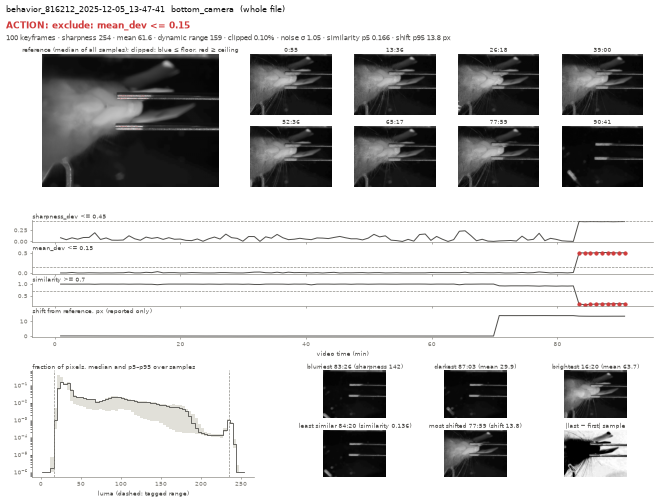

In [4]:
frames, samples, checks = whole["bottom_camera"]
bad = checks.set_index("check").loc["similarity >= 0.7", "samples"]
print(samples.loc[bad, ["video_time", "sharpness", "mean", "similarity"]].round(2))
fig = vqr.session_card(frames, samples, checks, f"{SESSION}  bottom_camera  (whole file)")

## 2. The task only, from the raw asset

No NWB is needed. `read_trial_times` reads trial start, go cue and trial
end from the session JSON in `behavior/` (the same Harp-clock values the
NWB trials table holds; it can read the URL directly).
`video_alignment.task_frame_window` puts the first start and last end on
video frames. It needs the Harp time of every CSV row: the timing QC
correction, with the trigger log when given, as in the kinematics pipeline.
Where that strict correction refuses a camera (for an error of a frame or
two), it falls back to the trigger log by frame number, else the raw Harp
column when no frames were lost. Mapping by subtracting the first
frame's Harp time instead would put the task end 315 s late on this
session, which dropped 187,024 frames.

In [5]:
behavior_json = f"{ASSET}/behavior/816212_2025-12-05_13-47-41.json"
trials = read_trial_times(behavior_json)
print(len(trials), "trials")
trials.head(3)

506 trials


,start_time,goCue_start_time,stop_time
0,4311.484480,4314.092256,4317.474496
1,4317.514496,4321.107296,4324.423488
2,4324.453504,4328.941376,4332.256480


In [6]:
trigger_log = fetch("behavior/raw.harp/BehaviorEvents/Event_94.bin")
windows = {}
for cam in CAMERAS:
    csv = fetch(f"behavior-videos/{cam}.csv")
    t = time.perf_counter()
    windows[cam] = task_frame_window(behavior_json, csv, trigger_log)
    start, end = windows[cam]
    print(f"{cam}: frames {start:,}-{end:,} = video {start / 500 / 60:.1f}-{end / 500 / 60:.1f} min "
          f"({time.perf_counter() - t:.1f} s); without the log: {task_frame_window(behavior_json, csv)}")

bottom_camera: frames 280,988-2,388,169 = video 9.4-79.6 min (4.2 s); without the log: (280988, 2388169)


side_camera_right: frames 281,419-2,389,107 = video 9.4-79.6 min (4.0 s); without the log: (281419, 2389107)


The task starts 9.4 minutes into the video (setup before the first
trial) and ends at 79.6 minutes; the empty rig follows from about 83. The
trigger log and the corrected timing give the same frames.
`vqq.sample_window` wraps this for the pipeline: it returns the window and
`"task"`, or `None` (the middle 50% of the file) and the reason.

In [7]:
task = {cam: run(url, cam, windows[cam]) for cam, url in CAMERAS.items()}
check_table(task)

bottom_camera: 100 keyframes in 41 s


side_camera_right: 100 keyframes in 44 s


,bottom_camera,side_camera_right
check,,
mean median <= 150,✓ 61.84,✓ 77.83
mean median >= 50,✓ 61.84,✓ 77.83
mean_dev <= 0.15,✓ 0,✓ 0
pct_clipped_high median <= 3.75,not checked,✓ 1.478
sharpness_dev <= 0.45,✓ 0,✓ 0
similarity >= 0.7,✓ 0,✓ 0
similarity p5 < 0.998,✓ 0.9153,✓ 0.9069
action,use,use


In [8]:
pd.DataFrame({
    cam: pd.concat([
        samples.median(numeric_only=True)[
            ["sharpness", "mean", "dynamic_range", "pct_clipped_high", "noise_sigma"]
        ].add_suffix(" median"),
        pd.Series({"sharpness_dev max": samples["sharpness_dev"].max(),
                   "mean_dev max": samples["mean_dev"].max(),
                   "similarity p5": samples["similarity"].quantile(0.05),
                   "shift p95": samples["shift"].quantile(0.95)}),
    ])
    for cam, (_, samples, _) in task.items()
}).round(3)

,bottom_camera,side_camera_right
sharpness median,249.277,382.486
mean median,61.842,77.834
dynamic_range median,158.000,212.000
pct_clipped_high median,0.101,1.478
noise_sigma median,1.049,1.473
sharpness_dev max,0.225,0.156
mean_dev max,0.028,0.036
similarity p5,0.915,0.907
shift p95,13.812,0.207


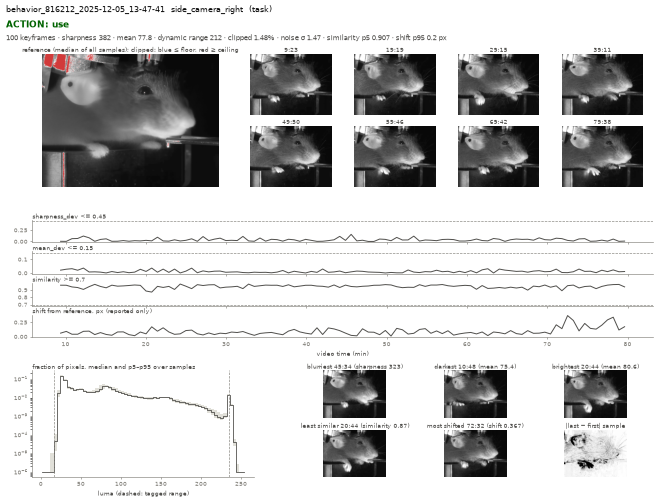

In [9]:
frames, samples, checks = task["side_camera_right"]
fig = vqr.session_card(frames, samples, checks, f"{SESSION}  side_camera_right  (task)")

## 3. A spout move reads as a camera shift

At about 71 min the bottom camera's `shift` jumps to 14 px and stays. The
overlay of the samples before and after shows that only the lick spouts
moved; the mouse and the rig are still registered. Phase correlation locks
onto the spouts' sharp edges. Tiled estimates split evenly between the two
motions, and correlation with the reference drops about as much for a spout
move (0.91) as for a real 6 px camera bump (0.86–0.90), so no whole-frame
metric separates them. `shift` is therefore reported but not checked;
`similarity >= 0.7` still catches gross changes.

,video_time,shift_x,shift_y,similarity
84,4137.69,-0.01,0.02,0.99
85,4180.19,-0.01,0.01,0.99
86,4222.69,-4.68,-9.96,0.91
87,4265.19,-9.51,-10.01,0.92


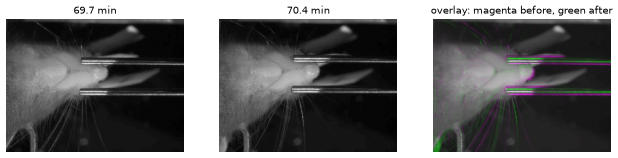

In [10]:
frames, s, _ = task["bottom_camera"]
jump = int(np.argmax(s["shift"].to_numpy() > 5))
before, after = frames[jump - 1] / 255, frames[jump] / 255
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].imshow(before, cmap="gray"); ax[0].set_title(f"{s.video_time[jump - 1] / 60:.1f} min")
ax[1].imshow(after, cmap="gray"); ax[1].set_title(f"{s.video_time[jump] / 60:.1f} min")
ax[2].imshow(np.clip(np.dstack([before, after, before]), 0, 1))
ax[2].set_title("overlay: magenta before, green after")
for a in ax:
    a.axis("off")
s.loc[jump - 2 : jump + 1, ["video_time", "shift_x", "shift_y", "similarity"]].round(2)

## 4. Outputs

`write_video_quality` writes, per camera, the samples table with every
metric and the luma histograms (parquet) and a JSON with the window note,
versions, checks and verdict. `scripts/video_quality_survey.py` runs all of
this on many sessions and builds a PDF of the cards.

In [11]:
out = Path(tempfile.mkdtemp())
for cam, (frames, samples, checks) in task.items():
    json_path, parquet_path = vqq.write_video_quality(samples, checks, out, cam, "task")
print(sorted(p.name for p in out.iterdir()))
print(json_path.read_text()[:900])

['video_quality_bottom_camera.json', 'video_quality_bottom_camera.parquet', 'video_quality_side_camera_right.json', 'video_quality_side_camera_right.parquet']
{
  "camera": "side_camera_right",
  "window": "task",
  "versions": {
    "aind_dynamic_foraging_behavior_video_analysis": "0.1.0",
    "aind_video_utils": "0.7.0"
  },
  "checks": [
    {
      "check": "sharpness_dev <= 0.45",
      "metric": "sharpness_dev",
      "over": "samples",
      "op": "<=",
      "value": 0.45,
      "observed": 0.0,
      "passed": true,
      "samples": []
    },
    {
      "check": "mean_dev <= 0.15",
      "metric": "mean_dev",
      "over": "samples",
      "op": "<=",
      "value": 0.15,
      "observed": 0.0,
      "passed": true,
      "samples": []
    },
    {
      "check": "similarity >= 0.7",
      "metric": "similarity",
      "over": "samples",
      "op": ">=",
      "value": 0.7,
      "observed": 0.0,
      "passed": true,
      "samples": []
    },
    {
      "check": "similari